<a href="https://colab.research.google.com/github/kendala545-dot/mis433/blob/main/Aaron_Kendall_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [8]:
# List all the column names:
imdb.columns

<bound method IndexOpsMixin.value_counts of Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')>

## Part 1: Data Manipulation

Redo the following to clean the data.

In [14]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [17]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.

# Convert 'Released_Year' to numeric, coercing errors to NaN
released_year_numeric = pd.to_numeric(imdb['Released_Year'], errors='coerce')

# Find rows where 'Released_Year' could not be converted (i.e., is NaN)
problematic_movie = imdb[released_year_numeric.isna()]

display(problematic_movie)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [18]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value

#we found this to be the apollo 13 movie which has released_year as pg and certificate as u released_year should be 1995 and certificate should be pg

apollo_13_index = imdb[imdb['Series_Title'] == 'Apollo 13'].index

# Correct the 'Released_Year' for Apollo 13 to '1995'
imdb.loc[apollo_13_index, 'Released_Year'] = '1995'

# Correct the 'Certificate' for Apollo 13 to 'PG'
imdb.loc[apollo_13_index, 'Certificate'] = 'PG'

print("Corrected values for Apollo 13:")
display(imdb.loc[apollo_13_index, ['Series_Title', 'Released_Year', 'Certificate']])

Corrected values for Apollo 13:


,Series_Title,Released_Year,Certificate
966,Apollo 13,1995,PG


In [19]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)

# Verify the data type change
print(imdb['Released_Year'].dtype)

int64


In [40]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
filtered_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]

# Show their title, released year, Certificate, and gross.
selected_columns = filtered_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']]

# Sort them in descending order of "Gross"
sorted_movies = selected_columns.sort_values(by='Gross', ascending=False)

display(sorted_movies)

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [23]:
# Does the sorting result looks right to you? What's the problem?
# The entries are not sorted in proper descending order

In [42]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe

filtered_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
selected_columns = filtered_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']].copy()

selected_columns['Gross'] = pd.to_numeric(
    selected_columns['Gross'].str.replace(',', ''),
    errors='coerce'
)

sorted_movies = selected_columns.sort_values(by='Gross', ascending=False)
display(sorted_movies)

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [44]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"

sorted_movies = selected_columns.sort_values(by='Gross', ascending=False)
display(sorted_movies)


,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [45]:
# Add a new column "Runtime_min" by removing the substring ' min' in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min'] = imdb['Runtime'].str.replace(' min', '').astype(int)

# Display the first few rows with the new column to verify
display(imdb[['Runtime', 'Runtime_min']].head())

,Runtime,Runtime_min
0,142 min,142
1,175 min,175
2,152 min,152
3,202 min,202
4,96 min,96


In [68]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
from datetime import datetime

current_year = datetime.now().year
imdb['Age_Year'] = current_year - imdb['Released_Year']

# Display the first few rows with the new column to verify
display(imdb[['Series_Title', 'Released_Year', 'Age_Year']].head())

,Series_Title,Released_Year,Age_Year
0,The Shawshank Redemption,1994,32
1,The Godfather,1972,54
2,The Dark Knight,2008,18
3,The Godfather: Part II,1974,52
4,12 Angry Men,1957,69


In [46]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10

# Display the first few rows with the new column to verify
display(imdb[['Series_Title', 'Released_Year', 'Decade']].head())

,Series_Title,Released_Year,Decade
0,The Shawshank Redemption,1994,1990
1,The Godfather,1972,1970
2,The Dark Knight,2008,2000
3,The Godfather: Part II,1974,1970
4,12 Angry Men,1957,1950


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

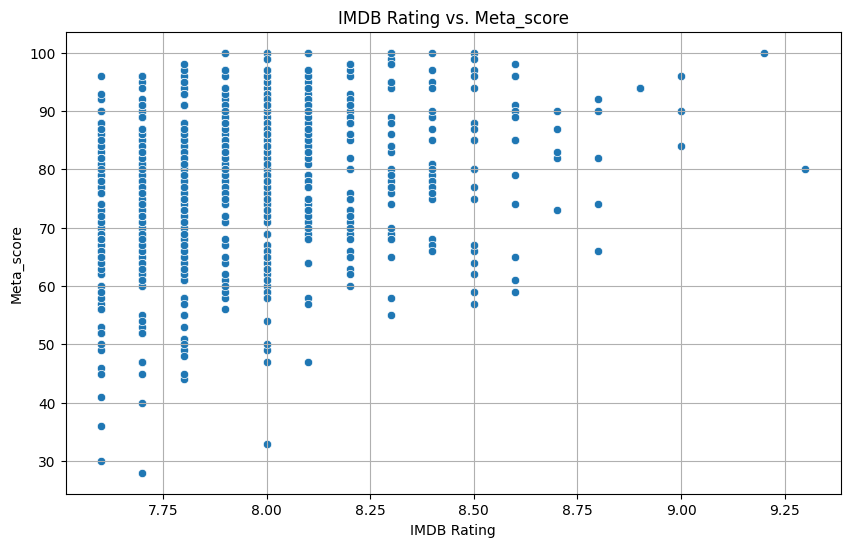

In [49]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IMDB_Rating', y='Meta_score', data=imdb)
plt.title('IMDB Rating vs. Meta_score')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta_score')
plt.grid(True)
plt.show()

# In a sentence or two, describe what this pair of scores suggests about the movies.
# It shows a general positive correlation between IMDB Rating and Meta_score.

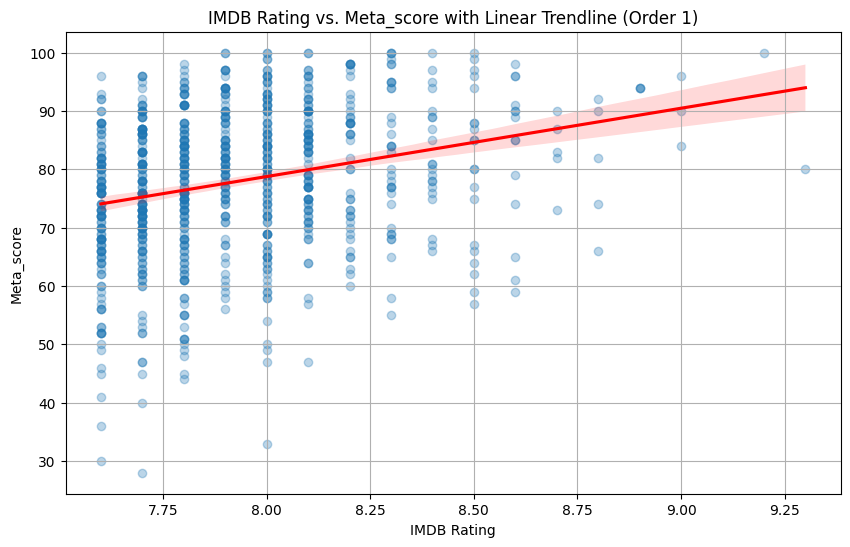

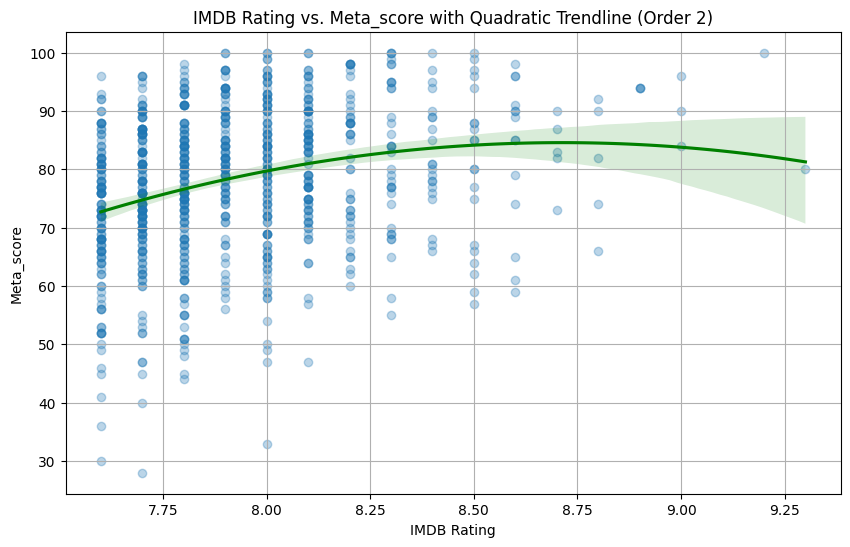

In [50]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.

plt.figure(figsize=(10, 6))
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('IMDB Rating vs. Meta_score with Linear Trendline (Order 1)')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta_score')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, order=2, scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title('IMDB Rating vs. Meta_score with Quadratic Trendline (Order 2)')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta_score')
plt.grid(True)
plt.show()

In [51]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
imdb[imdb['IMDB_Rating'] >= 9.0][['Series_Title', 'IMDB_Rating', 'Meta_score']]

# The Shawshank Redemption has the highest IMDB rating in the dataset, yet its Meta_score of 80 is noticeably lower than expected when compared to movies with similar IMDB ratings.

,Series_Title,IMDB_Rating,Meta_score
0,The Shawshank Redemption,9.3,80.0
1,The Godfather,9.2,100.0
2,The Dark Knight,9.0,84.0
3,The Godfather: Part II,9.0,90.0
4,12 Angry Men,9.0,96.0


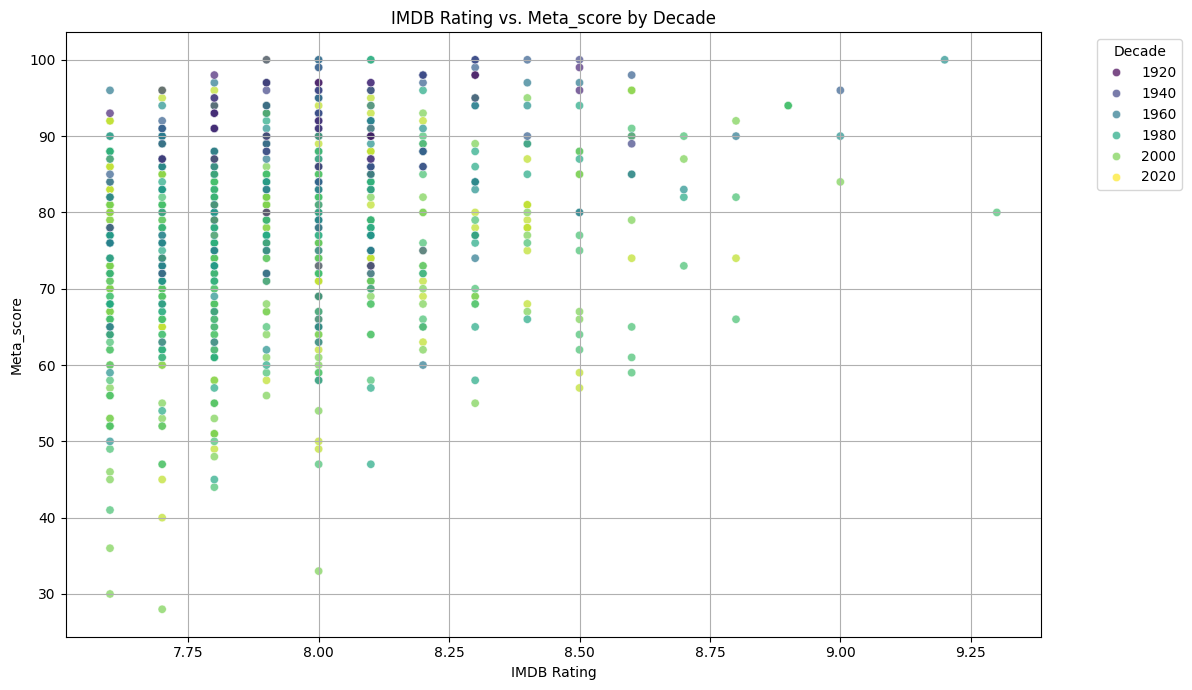

In [52]:
# In the scatterplot, use color to distinguish movies from different decades.

plt.figure(figsize=(12, 7))
sns.scatterplot(x='IMDB_Rating', y='Meta_score', hue='Decade', data=imdb, palette='viridis', alpha=0.7)
plt.title('IMDB Rating vs. Meta_score by Decade')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta_score')
plt.grid(True)
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2938/2433895669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')


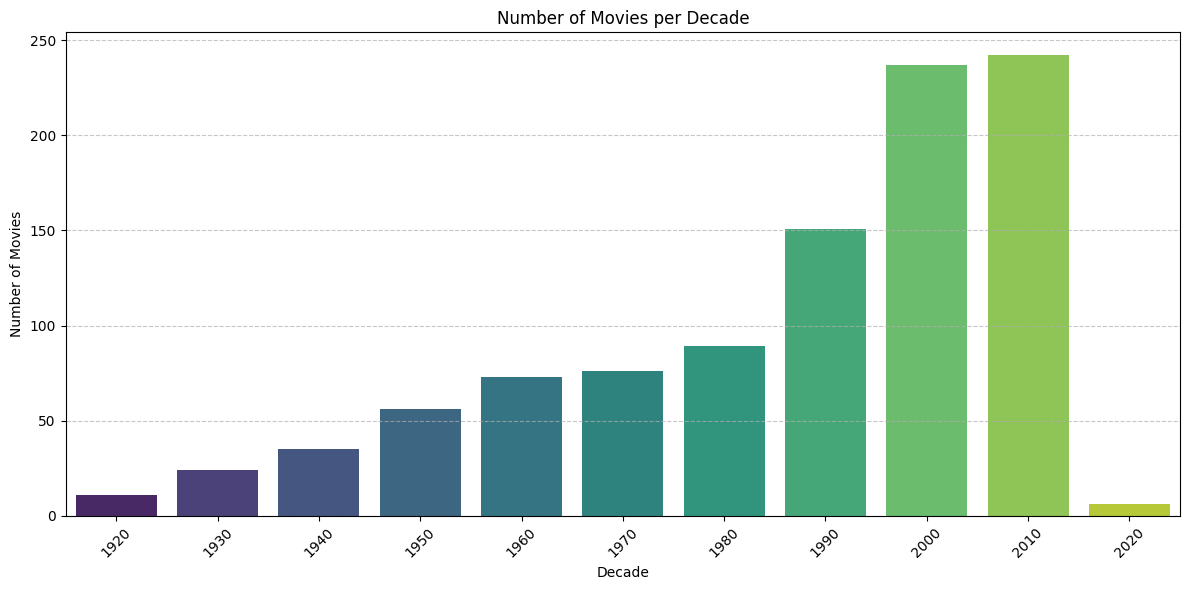

In [53]:
# Create a chart that shows how many movies fall in each decade.

decade_counts = imdb['Decade'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')
plt.title('Number of Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2938/1905257548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_percentages.index, y=decade_percentages.values, palette='viridis')


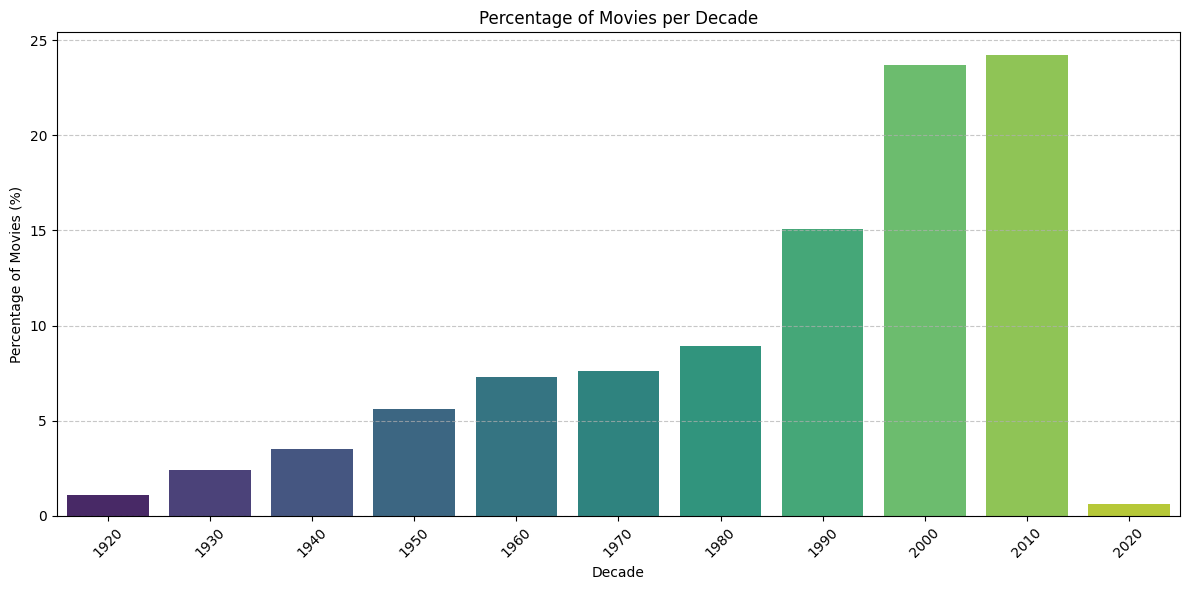

In [54]:
# Create a chart that shows the percentage of movies in each decade.

decade_percentages = (imdb['Decade'].value_counts(normalize=True) * 100).sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=decade_percentages.index, y=decade_percentages.values, palette='viridis')
plt.title('Percentage of Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Percentage of Movies (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2938/2570649667.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_directors.index, y=top_10_directors.values, palette='coolwarm')


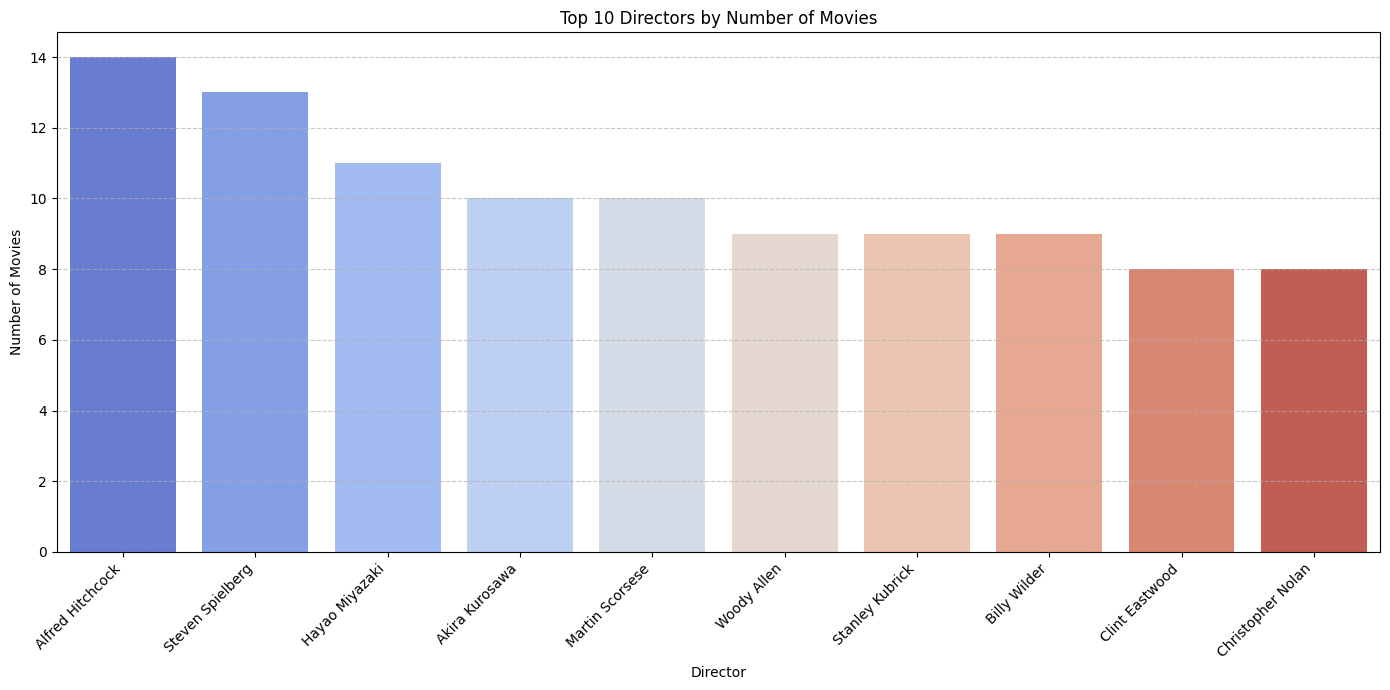

In [55]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.

top_10_directors = imdb['Director'].value_counts().head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_10_directors.index, y=top_10_directors.values, palette='coolwarm')
plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

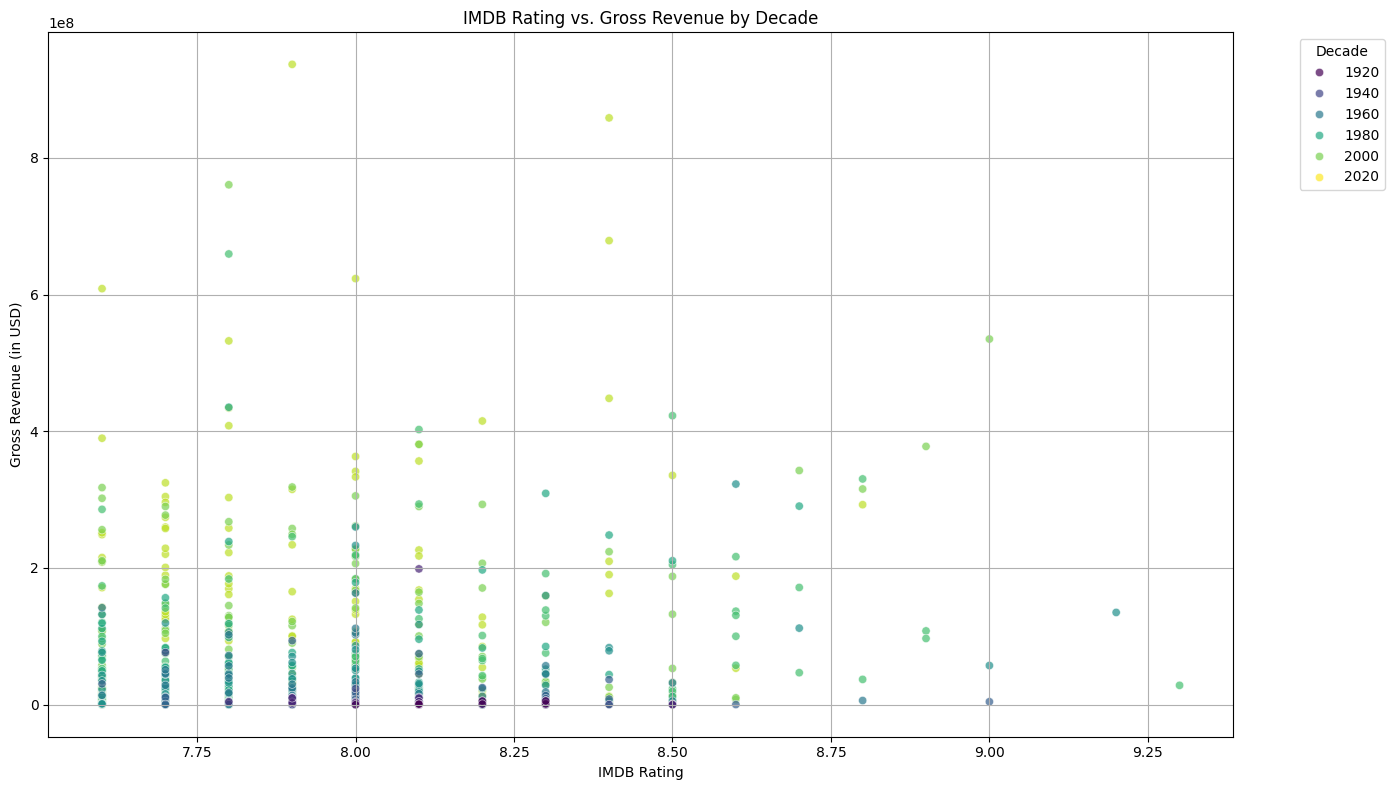

In [56]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.

# Ensure 'Gross' is numeric (clean if necessary)
if imdb['Gross'].dtype == 'object':
    imdb['Gross'] = imdb['Gross'].str.replace(',', '').astype(float)

plt.figure(figsize=(14, 8))
sns.scatterplot(x='IMDB_Rating', y='Gross', hue='Decade', data=imdb, palette='viridis', alpha=0.7)
plt.title('IMDB Rating vs. Gross Revenue by Decade')
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue (in USD)')
plt.grid(True)
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

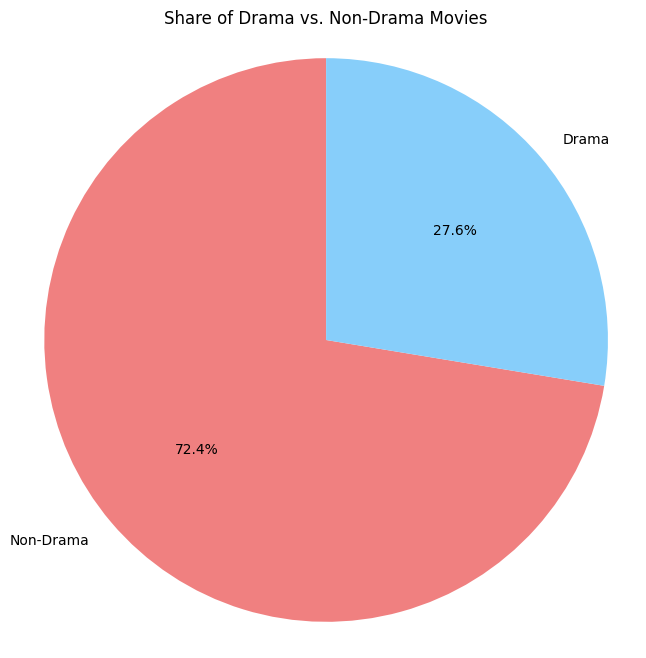

In [57]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.

imdb['Drama'] = imdb['Genre'].str.contains('Drama', case=False, na=False)

drama_counts = imdb['Drama'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(drama_counts, labels=['Non-Drama', 'Drama'], autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Share of Drama vs. Non-Drama Movies')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_2938/3666054453.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Decade', y='Gross', data=decade_gross, palette='magma')


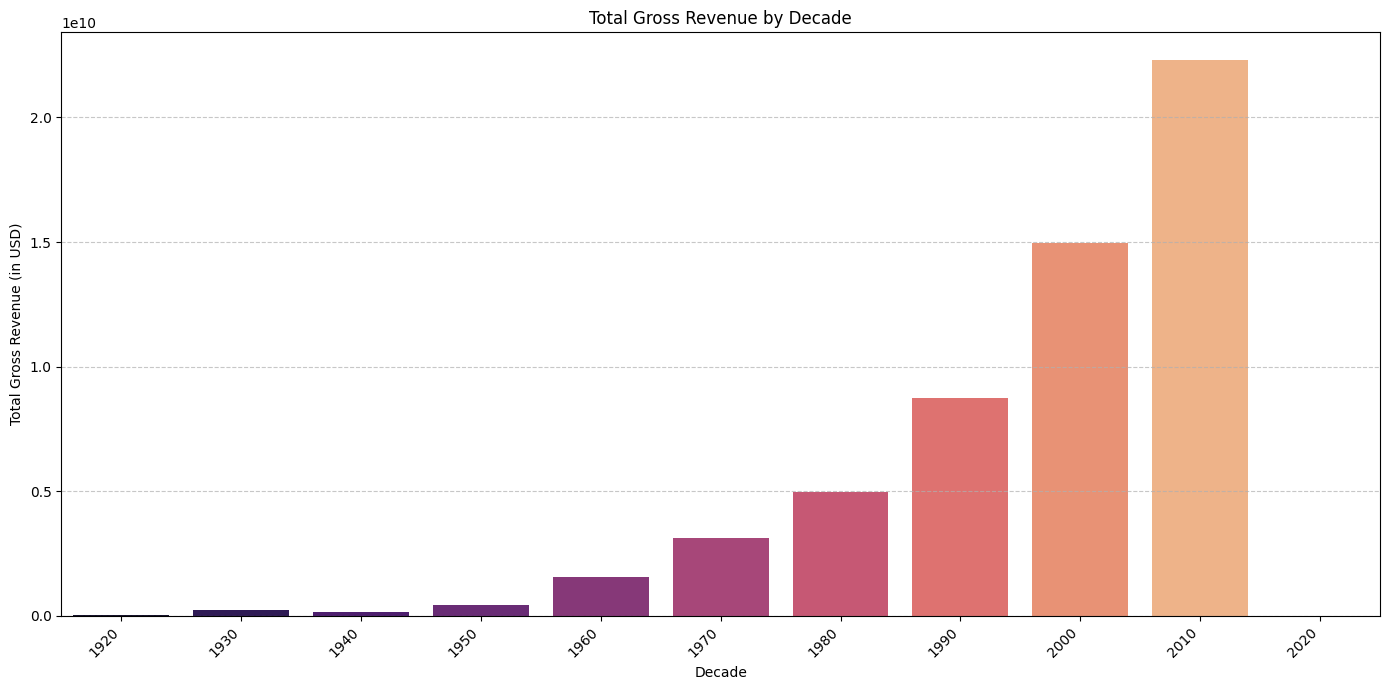

In [58]:
# Create a plot comparing gross revenue across decades.

decade_gross = imdb.groupby('Decade')['Gross'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Decade', y='Gross', data=decade_gross, palette='magma')
plt.title('Total Gross Revenue by Decade')
plt.xlabel('Decade')
plt.ylabel('Total Gross Revenue (in USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

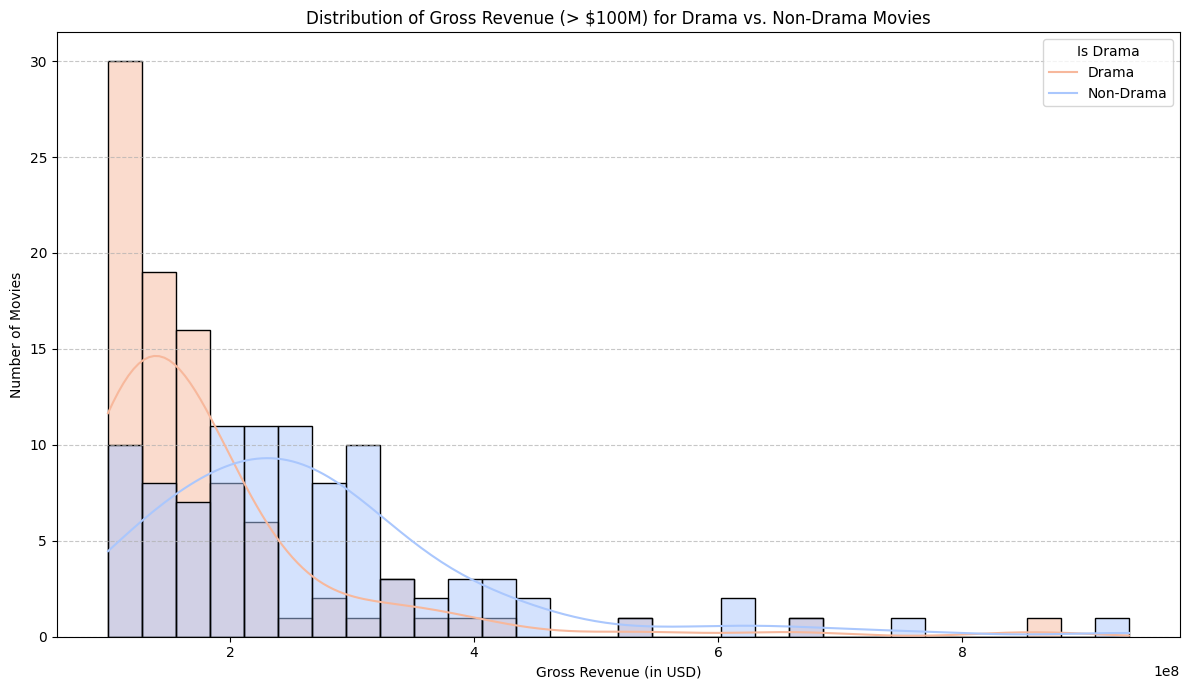

In [59]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

# Ensure 'Gross' is numeric (already done in a previous cell, but good to be defensive)
if imdb['Gross'].dtype == 'object':
    imdb['Gross'] = imdb['Gross'].str.replace(',', '').astype(float)

# Filter for movies with gross over $100 million
m_100_million = imdb[imdb['Gross'] > 100_000_000].copy()

plt.figure(figsize=(12, 7))
sns.histplot(data=m_100_million, x='Gross', hue='Drama', kde=True, palette='coolwarm', bins=30)
plt.title('Distribution of Gross Revenue (> $100M) for Drama vs. Non-Drama Movies')
plt.xlabel('Gross Revenue (in USD)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Is Drama', labels=['Drama', 'Non-Drama'])
plt.tight_layout()
plt.show()

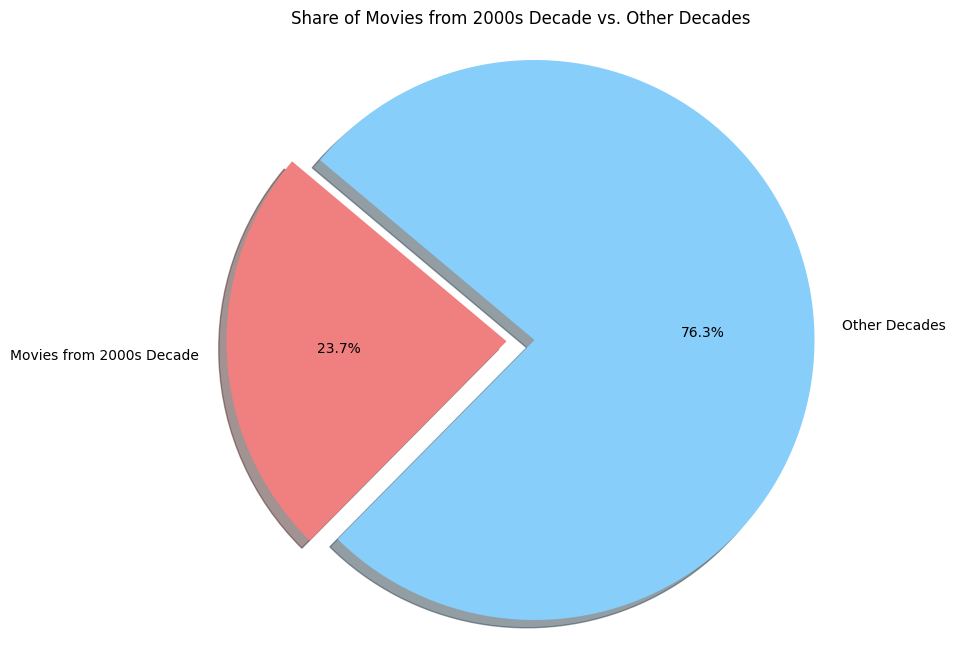

In [63]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: Create a pie chart showing the share of movies from decade 2000 vs. other decades

movies_2000s = imdb[imdb['Decade'] == 2000].shape[0]
other_movies = imdb.shape[0] - movies_2000s

labels = ['Movies from 2000s Decade', 'Other Decades']
sizes = [movies_2000s, other_movies]
colors = ['lightcoral', 'lightskyblue']
explode = (0.1, 0)  # explode 1st slice (2000s)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Share of Movies from 2000s Decade vs. Other Decades')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

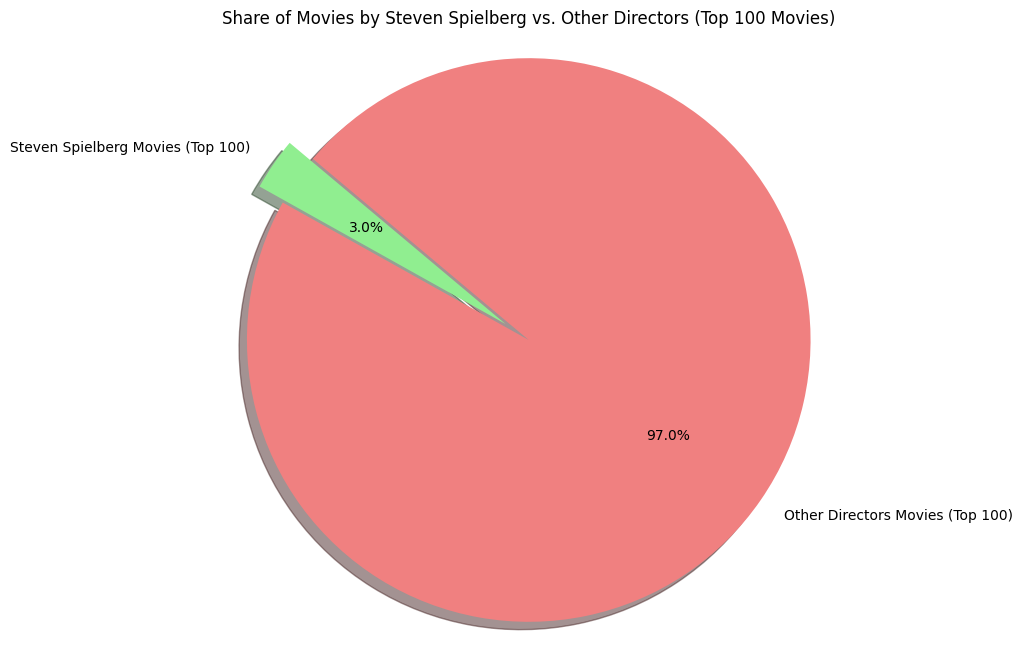

In [67]:
# Question 2: Create a pie chart showing the share of movies from Steven Spielberg vs top 100

# Consider only the first 100 movies from the imdb DataFrame
top_100_movies = imdb.head(100)

spielberg_movies_in_top_100 = top_100_movies[top_100_movies['Director'] == 'Steven Spielberg'].shape[0]
other_directors_movies_in_top_100 = top_100_movies.shape[0] - spielberg_movies_in_top_100

labels = ['Steven Spielberg Movies (Top 100)', 'Other Directors Movies (Top 100)']
sizes = [spielberg_movies_in_top_100, other_directors_movies_in_top_100]
colors = ['lightgreen', 'lightcoral']
explode = (0.1, 0)  # explode Steven Spielberg's slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Share of Movies by Steven Spielberg vs. Other Directors (Top 100 Movies)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()